# $(SA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model
from pmbrl.data import Experiment_Data

# Training

In [2]:
data = Experiment_Data()

data.generate_episodes(100)
data.build_training_dataset()
x, y = data.get_features_targets()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

In [3]:
model = Model()

loss_param=1e-5

trainer = model.train(x, y, num_epochs=5000, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.11943653970956802, 2.270392417907715]","[0.12090634554624557, 2.270287275314331]","[0.04760374128818512, 0.45394954085350037, 0.0...",1.981320,1.753140,0.262493
1,1,"[0.11864818632602692, 2.2793960571289062]","[0.1201307401061058, 2.2794528007507324]","[0.046021122485399246, 0.45122212171554565, 0....",1.983130,1.740995,0.261809
2,2,"[0.11787008494138718, 2.2885429859161377]","[0.11936551332473755, 2.2887635231018066]","[0.04447373002767563, 0.44845858216285706, 0.0...",1.984991,1.728934,0.261135
3,3,"[0.11711696535348892, 2.297835111618042]","[0.1186259537935257, 2.298222064971924]","[0.042966827750205994, 0.4455772936344147, 0.0...",1.986893,1.716953,0.260472
4,4,"[0.11639044433832169, 2.3073019981384277]","[0.11791018396615982, 2.307861804962158]","[0.04150369018316269, 0.4426065981388092, 0.02...",1.988837,1.705048,0.259821


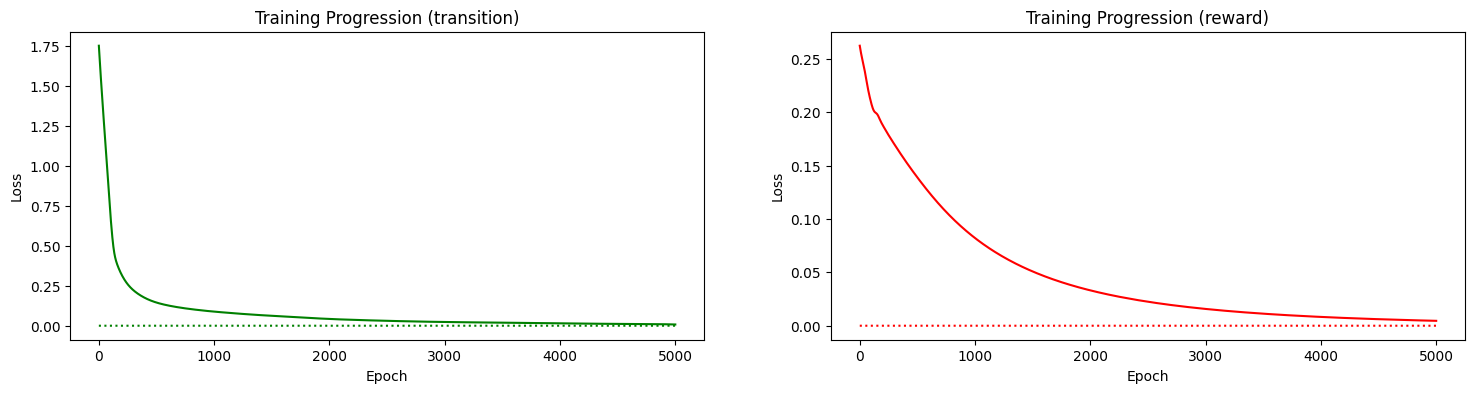

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

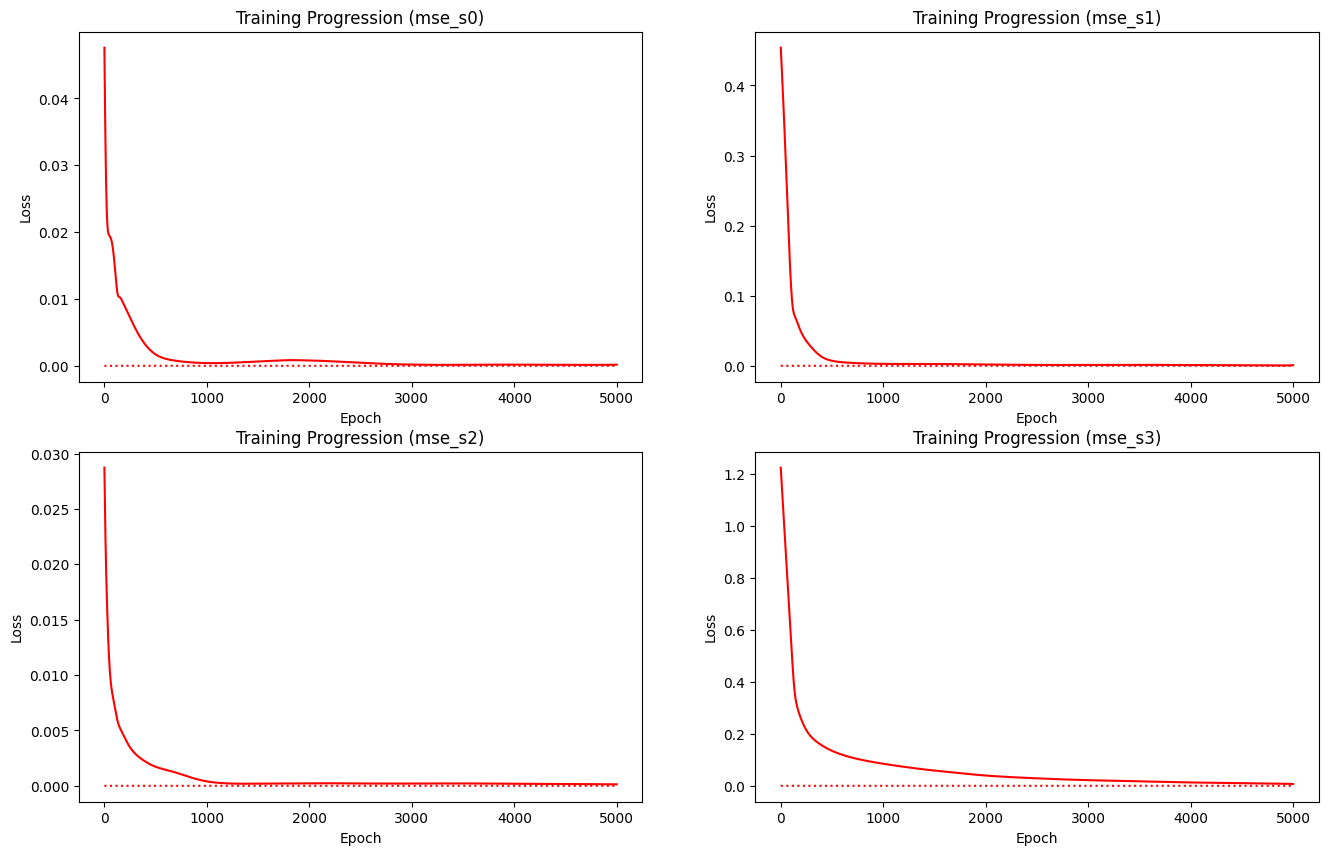

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = data.get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

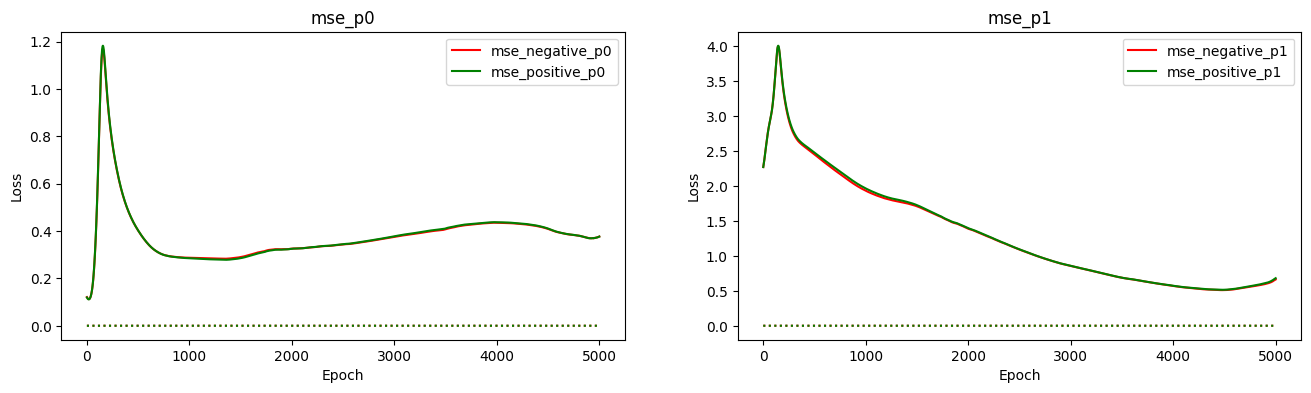

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = data.get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

# Evaluation

In [7]:
results = data.evaluate_model(model, n_episodes=10)
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_p,estimated_r
0,0,0,"(0.06, 1.6)","[-0.02, -0.015, -0.032, 0.043]",1,1.0,"[-0.02, 0.171, -0.031, -0.049]",1.0,1.0,"[-0.017, 0.357, -0.032, -0.141]","[-0.019, 0.35, -0.035, -0.19]","(-0.09, 0.74)",0.9
1,1,0,"(0.06, 1.6)","[-0.02, 0.171, -0.031, -0.049]",1,1.0,"[-0.017, 0.357, -0.032, -0.141]",1.0,1.0,"[-0.01, 0.543, -0.035, -0.233]","[-0.013, 0.538, -0.038, -0.259]","(-0.09, 0.63)",0.9
2,2,0,"(0.06, 1.6)","[-0.017, 0.357, -0.032, -0.141]",1,1.0,"[-0.01, 0.543, -0.035, -0.233]",0.0,1.0,"[0.001, 0.357, -0.04, -0.147]","[0.005, 0.38, -0.034, -0.117]","(-0.08, 0.5)",0.9
3,3,0,"(0.06, 1.6)","[-0.01, 0.543, -0.035, -0.233]",0,1.0,"[0.001, 0.357, -0.04, -0.147]",0.0,1.0,"[0.008, 0.171, -0.042, -0.062]","[0.014, 0.193, -0.039, -0.003]","(-0.09, 0.5)",0.9
4,4,0,"(0.06, 1.6)","[0.001, 0.357, -0.04, -0.147]",0,1.0,"[0.008, 0.171, -0.042, -0.062]",1.0,1.0,"[0.012, 0.358, -0.044, -0.155]","[0.004, 0.351, -0.05, -0.23]","(-0.09, 0.57)",0.9


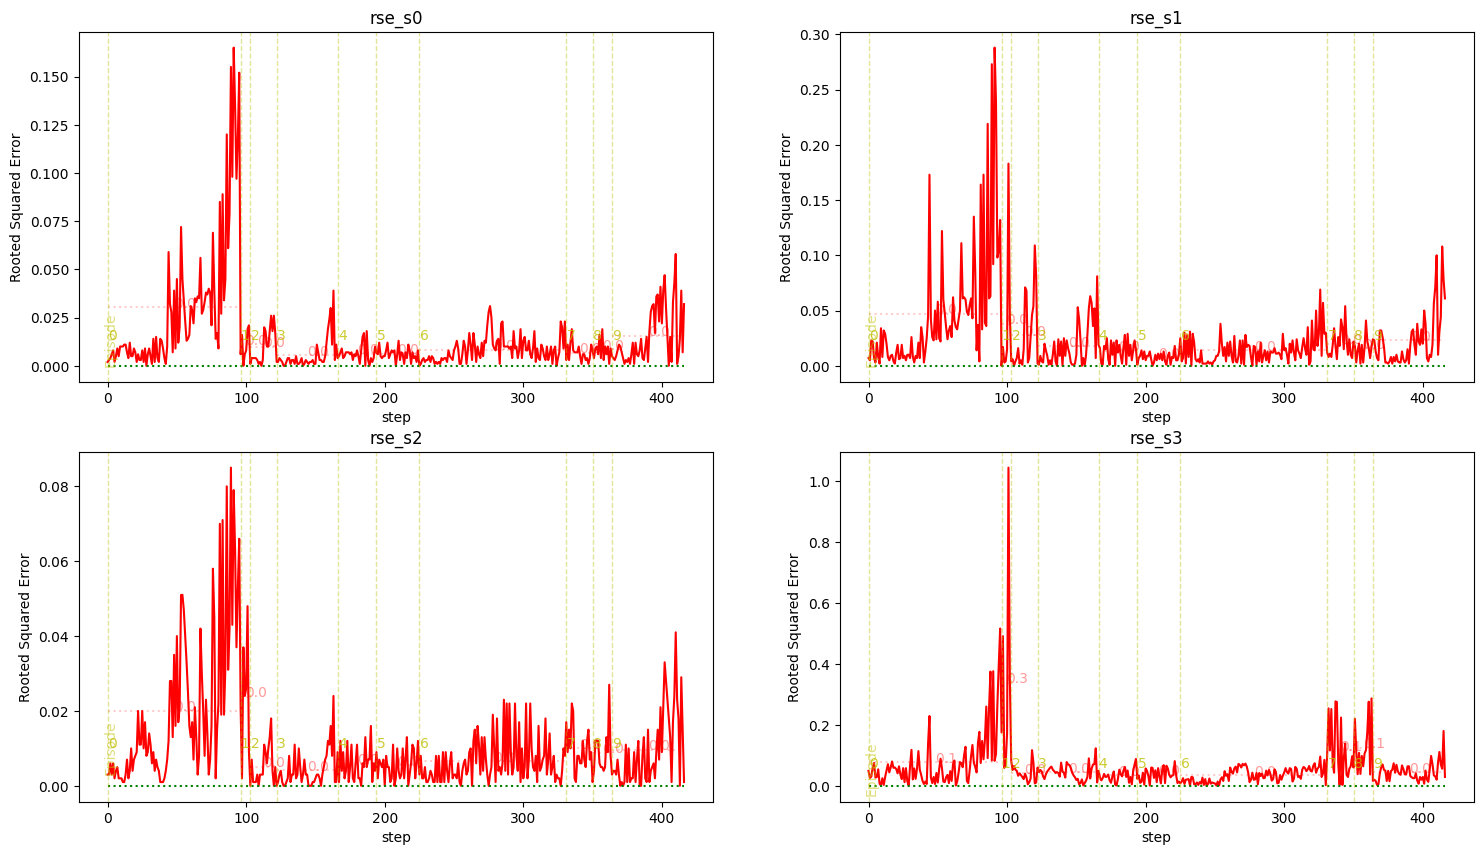

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

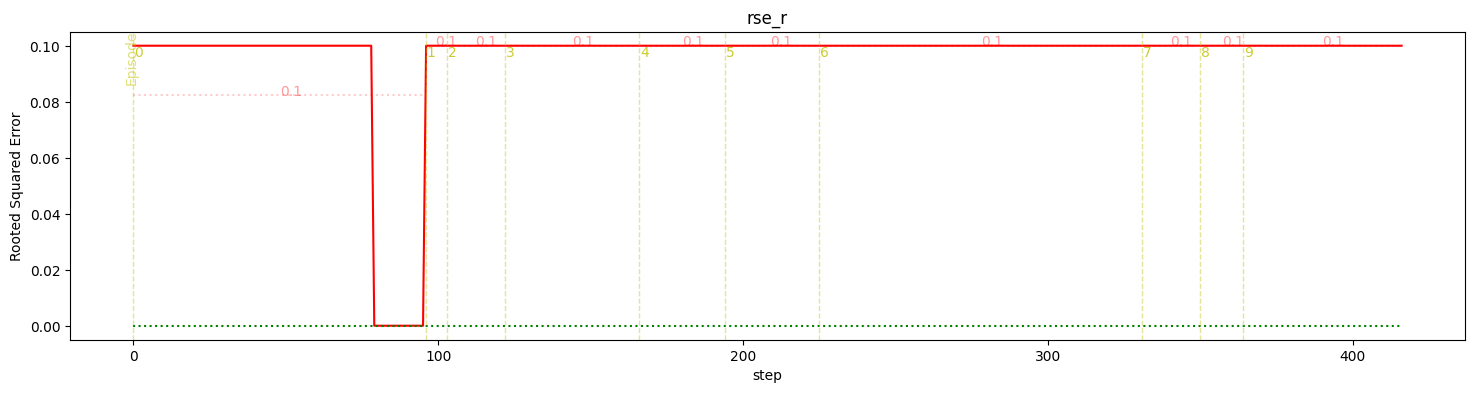

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

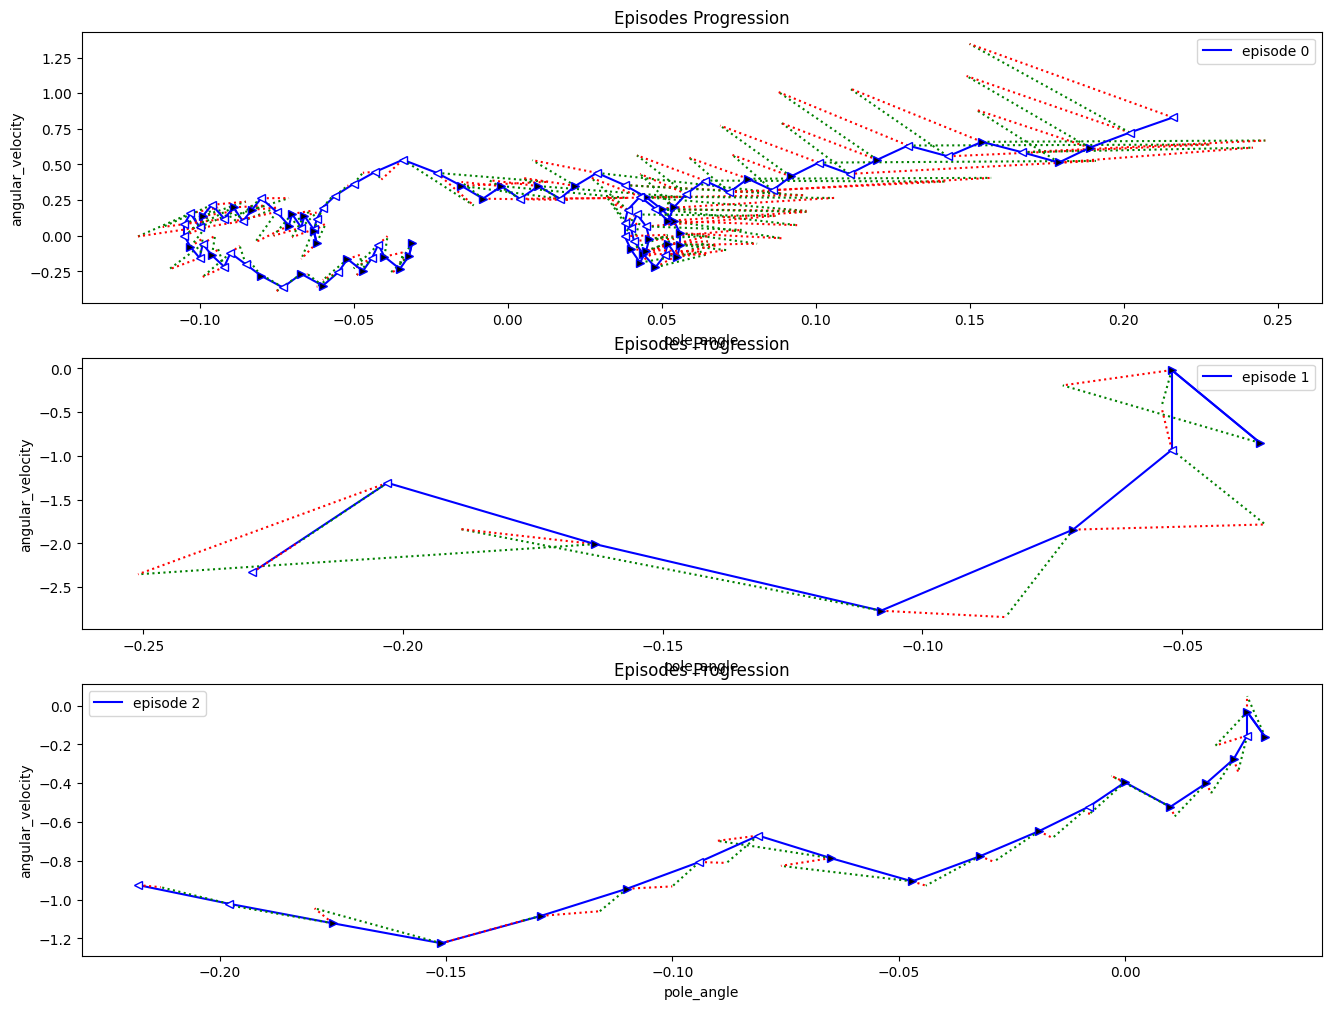

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()